<a href="https://colab.research.google.com/github/SwamiFr/sincnet-cough/blob/main/Sincnet_2D_CNN%2BBiGru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive daki bilgileri local dataya aktarma


In [ ]:
# Gerekli kütüphaneleri yükle
!pip install torchcodec
!pip install soundfile

import torch
import torchaudio
import os
import glob
import shutil
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import sys

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [ ]:
import os
import shutil
from google.colab import drive
from tqdm import tqdm

# 1. Drive'ı bağla
drive.mount('/content/drive')

# 2. Kaynak Yolları
# Sağlıklı verilerin olduğu klasör
healthy_source = '/content/drive/MyDrive/Colab Notebooks/İşaretlenenler/healthy/other'

# Astım verilerin olduğu klasör
asthma_source = '/content/drive/MyDrive/Colab Notebooks/İşaretlenenler/asthma'

# Hedef klasörler (Colab Local - Hızlı Disk)
base_target = '/content/dataset'
healthy_target_dir = os.path.join(base_target, 'healthy')
asthma_target_dir = os.path.join(base_target, 'asthma')

# Hedef klasörleri temizle ve yeniden oluştur
if os.path.exists(base_target):
    shutil.rmtree(base_target)
os.makedirs(healthy_target_dir)
os.makedirs(asthma_target_dir)

print("Dosyalar taranıyor ve kopyalanıyor...")

# Kopyalama Fonksiyonu
def copy_files(source_folder, target_folder, label_name):
    count = 0
    # os.walk alt klasörlerin hepsine girer
    for root, dirs, files in os.walk(source_folder):
        for file in files:
            if file.lower().endswith('.wav'):
                src_path = os.path.join(root, file)
                dst_path = os.path.join(target_folder, file)



                shutil.copy(src_path, dst_path)
                count += 1
    print(f"-> '{label_name}' için kopyalanan dosya sayısı: {count}")
    return count

# İşlemi Başlat
h_count = copy_files(healthy_source, healthy_target_dir, "Sağlıklı (healthy)")
a_count = copy_files(asthma_source, asthma_target_dir, "Astım (asthma)")

print(f"\nİşlem Tamamlandı!")
print(f"Toplam Ses Dosyası: {h_count + a_count}")

# Hata kontrolü:
if h_count == 0:
    print(f"UYARI: '{healthy_source}' konumunda hiç .wav dosyası bulunamadı! Drive yolunu kontrol et.")
if a_count == 0:
    print(f"UYARI: '{asthma_source}' konumunda hiç .wav dosyası bulunamadı! Drive yolunu kontrol et.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dosyalar taranıyor ve kopyalanıyor...
-> 'Sağlıklı (healthy)' için kopyalanan dosya sayısı: 721
-> 'Astım (asthma)' için kopyalanan dosya sayısı: 346

İşlem Tamamlandı!
Toplam Ses Dosyası: 1067


Veri Yükleyici (Dataset) ve Eğitim/Test Ayrımı

In [ ]:
# --- ADIM 2: DATASET (MEL SPECTROGRAM) ---

import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import glob
import os

TARGET_SAMPLE_RATE = 16000
INPUT_LENGTH = 48000

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SAMPLE_RATE,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

class RespiratoryDataset(Dataset):
    def __init__(self, file_list, labels):

        self.file_list = file_list
        self.labels = labels

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):

        file_path = self.file_list[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(file_path)

        if sr != TARGET_SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, TARGET_SAMPLE_RATE)
            waveform = resampler(waveform)

        if waveform.shape[1] < INPUT_LENGTH:
            pad = INPUT_LENGTH - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :INPUT_LENGTH]

        mel = mel_transform(waveform)
        mel = torch.log(mel + 1e-9)

        return mel, torch.tensor(label)

In [ ]:
# -----------------------------
# DATASET DOSYALARINI TOPLA
# -----------------------------

healthy_files = glob.glob("/content/dataset/healthy/*.wav")
asthma_files = glob.glob("/content/dataset/asthma/*.wav")

files = healthy_files + asthma_files
labels = [0]*len(healthy_files) + [1]*len(asthma_files)

print("Healthy:", len(healthy_files))
print("Asthma:", len(asthma_files))

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

train_files, test_files, train_labels, test_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train:", len(train_files))
print("Test:", len(test_files))

# -----------------------------
# DATASET OLUŞTUR
# -----------------------------

train_dataset = RespiratoryDataset(train_files, train_labels)
test_dataset = RespiratoryDataset(test_files, test_labels)

# -----------------------------
# DATALOADER
# -----------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Dataloader hazır.")

Healthy: 721
Asthma: 346
Train: 853
Test: 214
Dataloader hazır.


CNN + BiGru

In [ ]:
import torch
import torch.nn as nn

class CNN_BiGRU(nn.Module):

    def __init__(self, num_classes=2):
        super(CNN_BiGRU, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.bigru = nn.GRU(
            input_size=128*16,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.cnn(x)

        b,c,f,t = x.size()

        x = x.permute(0,3,1,2)
        x = x.reshape(b,t,c*f)

        x,_ = self.bigru(x)

        x = x[:,-1,:]

        x = self.fc(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_BiGRU(num_classes=2).to(device)

print(model)

CNN_BiGRU(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bigru): GRU(2048, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


Eğitim (Training) Döngüsü

In [ ]:
# --- ADIM 4: GÜNCELLENMİŞ EĞİTİM KODU (IoU, F1, Dice Dahil) ---

import torch
import torch.optim as optim
import torch.nn as nn
import copy
import sys
from tqdm import tqdm
from sklearn.metrics import f1_score, jaccard_score

# -----------------------------
# EPOCH FONKSİYONU
# -----------------------------
train_f1_history = []
test_f1_history = []

train_iou_history = []
test_iou_history = []

def run_epoch(loader, is_train=True):

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    desc = "Eğitim" if is_train else "Test"
    loop = tqdm(loader, desc=desc, leave=False, file=sys.stdout)

    for inputs, labels in loop:

        inputs = inputs.to(device)
        labels = labels.to(device)


        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:

                # NaN koruması
                if torch.isnan(loss):
                    continue

                loss.backward()

                # Gradient Clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)
    acc = 100 * correct / total

    # -----------------------------
    # METRİKLER
    # -----------------------------

    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    iou = jaccard_score(all_labels, all_preds, average='binary', zero_division=0)

    # Binary classification'da Dice = F1
    dice = f1

    return avg_loss, acc, f1, iou, dice


# -----------------------------
# OPTIMIZER & LOSS
# -----------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-3
)

criterion = nn.CrossEntropyLoss()

EPOCHS = 30

# -----------------------------
# EARLY STOPPING
# -----------------------------

patience = 5
best_loss = float('inf')
counter = 0

best_model_wts = copy.deepcopy(model.state_dict())

print(f"\n--- GELİŞMİŞ EĞİTİM BAŞLIYOR (Cihaz: {device}) ---\n")

# -----------------------------
# TRAINING LOOP
# -----------------------------

for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1, train_iou, train_dice = run_epoch(
        train_loader,
        is_train=True
    )

    test_loss, test_acc, test_f1, test_iou, test_dice = run_epoch(
        test_loader,
        is_train=False
    )
    train_f1_history.append(train_f1)
    test_f1_history.append(test_f1)

    train_iou_history.append(train_iou)
    test_iou_history.append(test_iou)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(
        f"TRAIN -> Loss: {train_loss:.4f} | "
        f"Acc: %{train_acc:.2f} | "
        f"F1: {train_f1:.3f} | "
        f"IoU: {train_iou:.3f}"
    )

    print(
        f"TEST  -> Loss: {test_loss:.4f} | "
        f"Acc: %{test_acc:.2f} | "
        f"F1: {test_f1:.3f} | "
        f"IoU: {test_iou:.3f}"
    )

    # -----------------------------
    # EARLY STOPPING KONTROL
    # -----------------------------

    if test_loss < best_loss:

        best_loss = test_loss
        best_model_wts = copy.deepcopy(model.state_dict())

        counter = 0

        torch.save(model.state_dict(), "en_iyi_model.pth")

        print("   -> (Model Kaydedildi)")

    else:

        counter += 1

        print(f"   -> İyileşme yok. Sayaç: {counter}/{patience}")

        if counter >= patience:

            print("\n--- ERKEN DURDURMA (EARLY STOPPING) ---")
            print("Model overfitting yapmaya başladı.")
            break

    print("-" * 60)


# -----------------------------
# EN İYİ MODELİ GERİ YÜKLE
# -----------------------------

model.load_state_dict(best_model_wts)

print(f"\nEğitim bitti.")
print(f"En iyi model yüklendi. (Best Test Loss: {best_loss:.4f})")


--- GELİŞMİŞ EĞİTİM BAŞLIYOR (Cihaz: cuda) ---

Epoch 1/30
TRAIN -> Loss: 0.1979 | Acc: %93.43 | F1: 0.897 | IoU: 0.813
TEST  -> Loss: 0.4051 | Acc: %85.05 | F1: 0.781 | IoU: 0.640
   -> (Model Kaydedildi)
------------------------------------------------------------
Epoch 2/30
TRAIN -> Loss: 0.1764 | Acc: %93.43 | F1: 0.898 | IoU: 0.815
TEST  -> Loss: 0.3330 | Acc: %89.72 | F1: 0.851 | IoU: 0.741
   -> (Model Kaydedildi)
------------------------------------------------------------
Epoch 3/30
TRAIN -> Loss: 0.1447 | Acc: %95.08 | F1: 0.925 | IoU: 0.860
TEST  -> Loss: 0.4703 | Acc: %86.92 | F1: 0.818 | IoU: 0.692
   -> İyileşme yok. Sayaç: 1/5
------------------------------------------------------------
Epoch 4/30
TRAIN -> Loss: 0.1201 | Acc: %96.48 | F1: 0.946 | IoU: 0.897
TEST  -> Loss: 0.5006 | Acc: %89.25 | F1: 0.852 | IoU: 0.742
   -> İyileşme yok. Sayaç: 2/5
------------------------------------------------------------
Epoch 5/30
TRAIN -> Loss: 0.1253 | Acc: %96.60 | F1: 0.948 | Io

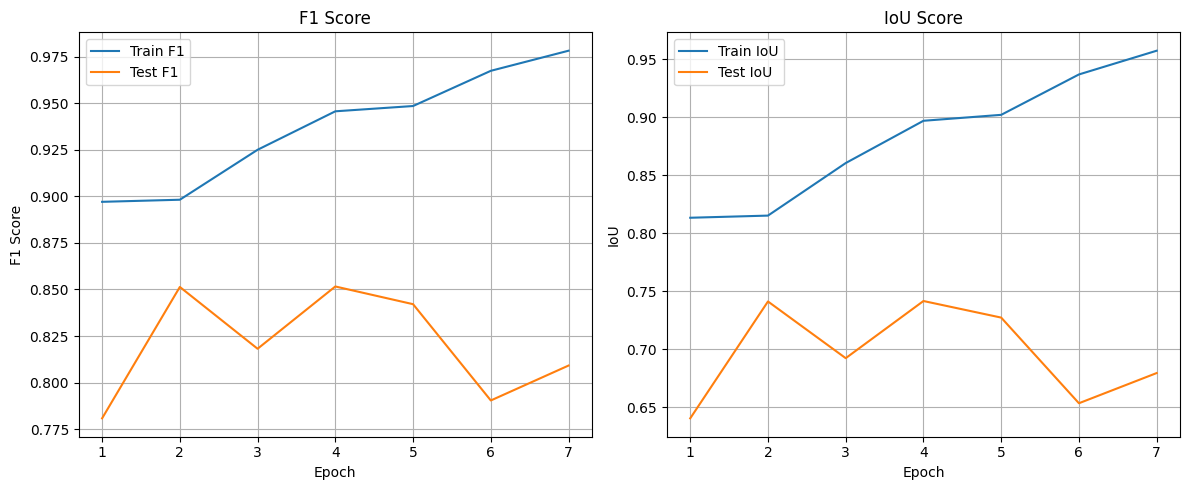

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_f1_history)+1)

plt.figure(figsize=(12,5))

# F1 SCORE
plt.subplot(1,2,1)
plt.plot(epochs, train_f1_history, label="Train F1")
plt.plot(epochs, test_f1_history, label="Test F1")
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.legend()
plt.grid()

# IoU
plt.subplot(1,2,2)
plt.plot(epochs, train_iou_history, label="Train IoU")
plt.plot(epochs, test_iou_history, label="Test IoU")
plt.title("IoU Score")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

SEgmente ve tahmin


In [ ]:
import librosa
import torch
import torch.nn.functional as F
import torchaudio
import numpy as np
import os

# -------------------------
# AYARLAR
# -------------------------

TARGET_SAMPLE_RATE = 16000
INPUT_LENGTH = 48000  # 3 saniye
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SAMPLE_RATE,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

# -------------------------
# TEK SEGMENT TAHMİN
# -------------------------

def process_and_predict(segment, sr, model):

    # tensor'a çevir
    tensor = torch.from_numpy(segment).float()

    # boyutlandırma
    if tensor.shape[0] > INPUT_LENGTH:

        center = tensor.shape[0] // 2
        start = center - (INPUT_LENGTH // 2)

        tensor = tensor[start:start + INPUT_LENGTH]

    elif tensor.shape[0] < INPUT_LENGTH:

        padding = INPUT_LENGTH - tensor.shape[0]
        tensor = F.pad(tensor, (0, padding))

    # waveform shape -> [1, 48000]
    waveform = tensor.unsqueeze(0)

    # -------------------------
    # MEL SPECTROGRAM
    # -------------------------

    mel = mel_transform(waveform)
    mel = torch.log(mel + 1e-9)

    # CNN input shape -> [1,1,128,time]
    input_tensor = mel.unsqueeze(0).to(DEVICE)

    # -------------------------
    # MODEL TAHMİN
    # -------------------------

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probs = F.softmax(output, dim=1)

        conf, pred = torch.max(probs, 1)

    return pred.item(), conf.item()


# -------------------------
# SES DOSYASI ANALİZ
# -------------------------

def analyze_audio_file(file_path):

    print(f"ANALİZ BAŞLIYOR: {file_path}")
    print("-" * 50)

    if not os.path.exists(file_path):
        print("HATA: Dosya bulunamadı!")
        return

    try:
        y, sr = librosa.load(file_path, sr=TARGET_SAMPLE_RATE)
    except Exception as e:
        print(f"Dosya okuma hatası: {e}")
        return

    # -------------------------
    # SEGMENTATION
    # -------------------------

    intervals = librosa.effects.split(y, top_db=20)

    votes = {"healthy": 0, "asthma": 0}

    print(f"Tespit edilen ses parçası sayısı: {len(intervals)}\n")

    for i, (start, end) in enumerate(intervals):

        segment = y[start:end]

        # çok kısa sesleri at
        if len(segment) < (0.2 * TARGET_SAMPLE_RATE):
            continue

        label_idx, confidence = process_and_predict(segment, sr, model)

        label_str = "SAĞLIKLI" if label_idx == 0 else "ASTIM"

        color = "\033[92m" if label_idx == 0 else "\033[91m"
        reset = "\033[0m"

        print(
            f"Parça {i+1}: {color}{label_str}{reset} "
            f"(Güven: %{confidence*100:.2f}) "
            f"- Süre: {len(segment)/sr:.2f}sn"
        )

        # oy sistemi
        if confidence > 0.60:

            if label_idx == 0:
                votes["healthy"] += 1
            else:
                votes["asthma"] += 1

    # -------------------------
    # GENEL RAPOR
    # -------------------------

    print("-" * 50)
    print("GENEL RAPOR:")

    total_votes = votes["healthy"] + votes["asthma"]

    if total_votes == 0:

        print("Yeterli netlikte öksürük tespit edilemedi.")

        return

    print(f"Astım Oyu: {votes['asthma']}")
    print(f"Sağlıklı Oyu: {votes['healthy']}")

    if votes["asthma"] > votes["healthy"]:

        print("\nSONUÇ: ⚠️ BU SES ASTIM BELİRTİLERİ GÖSTERİYOR ⚠️")

    elif votes["healthy"] > votes["asthma"]:

        print("\nSONUÇ: ✅ BU SES SAĞLIKLI GÖRÜNÜYOR ✅")

    else:

        print("\nSONUÇ: ⚖️ DURUM BELİRSİZ")


# -------------------------
# ÇALIŞTIR
# -------------------------

target_file = "/content/WhatsApp-Ptt-2026-03-09-at-12.53.58.wav"

analyze_audio_file(target_file)

ANALİZ BAŞLIYOR: /content/WhatsApp-Ptt-2026-03-09-at-12.53.58.wav
--------------------------------------------------
Tespit edilen ses parçası sayısı: 3

Parça 1: SAĞLIKLI (Güven: %99.34) - Süre: 0.42sn
Parça 2: SAĞLIKLI (Güven: %99.30) - Süre: 0.38sn
Parça 3: SAĞLIKLI (Güven: %99.37) - Süre: 0.42sn
--------------------------------------------------
GENEL RAPOR:
Astım Oyu: 0
Sağlıklı Oyu: 3

SONUÇ: ✅ BU SES SAĞLIKLI GÖRÜNÜYOR ✅


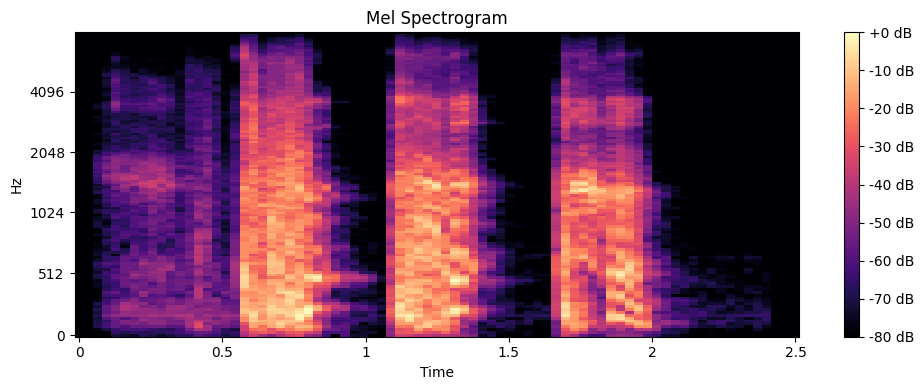

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# WAV dosyası
file_path = "/content/WhatsApp-Ptt-2026-03-09-at-12.53.58.wav"

# yükle
y, sr = librosa.load(file_path, sr=16000)

# mel spectrogram
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

# çizdir
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()